# Setup
- Run the model on random data
- use gathered data to estimate SHAP values

In [1]:
import torch
import numpy as np
import shap
from zx_env import extract_circuit
from zx_env import random_circuit
from TreePolicy import start_tree
from ppo import make_env
import ray
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import hydra
from omegaconf import DictConfig, OmegaConf, read_write
from model import BundleNet
import os

class DummyExtractor(torch.nn.Module):
    def __init__(self, model) -> None:
        super().__init__()
        self.model =model
        self.model.eval()
    def forward(self,x):
        x=torch.tensor(x)
        with torch.inference_mode():
            return self.model(x)[0].detach().numpy()



class Exploration(Dataset):
    def __init__(self, trees):
        super().__init__()
        self.trees=trees
        self.items = []
        for t in trees:
            for i in t.infos:
                self.items+=[i["feats"]]
        # deduplicate
        self.items = torch.unique(torch.stack(self.items),dim=0)
        print("items",self.items.shape)
    def __getitem__(self,idx):
        return self.items[idx]
    def __len__(self):
        return len(self.items)

@ray.remote
def deploy_agents(cfg, state, agent):
    env = make_env(cfg, "cpu")
    start = state.to_graph()
    next_obs = None
    for it in range(cfg.validation.search_loops):
        print("LOOP ROUND", it)
        next_obs, info = env.reset(initital_circuit_graph=start)
        next_obs = start_tree(next_obs.Graph, next_obs.state_zx_graph, info=info)
        for step in range(0, cfg.algorithm.num_steps):
            # ALGO LOGIC: action logic
            with torch.no_grad():
                # make a temporary batch from our data:
                effect, total_log, _, value = next_obs.select(agent)

            # TRY NOT TO MODIFY: execute the game and log data.
            new_tree, rew, term, trunc, info = next_obs.expand(effect, env)
            next_done = np.logical_or(term, trunc)
            next_obs, next_done = (
                new_tree,
                torch.Tensor(next_done),
            )
        print(
            "=====" * 5 + "\n",
            f"result of iteration {it}",
            extract_circuit(next_obs.get_best_node())[0].twoqubitcount(),
            "\n" + "=====" * 5,
        )
        start = extract_circuit(next_obs.get_best_node().clone())[0].to_graph()

    return (
        next_obs
    )  #

def get_data(cfg,agent,size_data):
    datas = [random_circuit(
                    n_qubit=cfg.validation.n_qubit,
                    num_gates=cfg.validation.n_gate,
                    p_two_qubit=cfg.validation.p_two_qubit,
                    p_H=cfg.validation.p_H,
                    p_z=cfg.validation.p_z,
                    p_x=cfg.validation.p_x,
                    many_pi_gates=cfg.validation.many_pi_gates,
                    clifford_plus_T=cfg.validation.clifford_plus_T,
                ) for _ in range(size_data)]
    res=[]
    for d in datas:
        res.append(deploy_agents.remote(cfg,d,agent))
    dataset = Exploration(ray.get(res))
    return dataset






2024-07-26 13:23:09,806	INFO util.py:154 -- Outdated packages:
  ipywidgets==7.8.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
ip_head="127.0.1.1:6379"
ray.init(address=ip_head)

2024-07-26 13:23:09,827	INFO worker.py:1540 -- Connecting to existing Ray cluster at address: 127.0.1.1:6379...
2024-07-26 13:23:09,854	INFO worker.py:1724 -- Connected to Ray cluster.
E0726 13:23:09.918533300   23525 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:23:09.9177437+02:00"}


Python version:,3.10.13
Ray version:,2.9.2


In [3]:
from hydra import initialize, initialize_config_module, initialize_config_dir, compose
print("environment",ip_head)
print("Nodes in the Ray cluster:")
print(ray.nodes())

with initialize(version_base=None, config_path="conf"):
    cfg = compose( config_name="config.yaml",overrides=["exp_name='test'", 
        "validation.model_path='runs/QACI_graph_optim__1024depth_with_restarts_64hidden_8_envs_optimized__1__1721914766/saves/model-409600.pth'",
        "+env=more_complex",
        "+model=GATActionModel",
        "model.model_type=ActionAtt",
        "+algorithm=PPO",
        "model.hidden_dim=64"])
print(cfg)

environment 127.0.1.1:6379
Nodes in the Ray cluster:
[{'NodeID': '048df8875a7a552cc25db07ef46ae7d08b2f159df8e8912451ca60b0', 'Alive': True, 'NodeManagerAddress': '127.0.1.1', 'NodeManagerHostname': 'r11873', 'NodeManagerPort': 60896, 'ObjectManagerPort': 60895, 'ObjectStoreSocketName': '/tmp/ray/session_2024-07-25_15-09-06_042956_2493/sockets/plasma_store', 'RayletSocketName': '/tmp/ray/session_2024-07-25_15-09-06_042956_2493/sockets/raylet', 'MetricsExportPort': 62866, 'NodeName': '127.0.1.1', 'RuntimeEnvAgentPort': 64620, 'alive': True, 'Resources': {'node:127.0.1.1': 1.0, 'node:__internal_head__': 1.0, 'CPU': 8.0, 'object_store_memory': 699826176.0, 'memory': 1399652352.0}, 'Labels': {'ray.io/node_id': '048df8875a7a552cc25db07ef46ae7d08b2f159df8e8912451ca60b0'}}]
{'validation': {'model_path': 'runs/QACI_graph_optim__1024depth_with_restarts_64hidden_8_envs_optimized__1__1721914766/saves/model-409600.pth', 'n_qubit': 5, 'n_gate': 80, 'p_two_qubit': 0.25, 'p_H': 0.25, 'p_z': 0.25, 'p_x

/home/alexander/miniforge3/envs/generalML/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


In [4]:
path = cfg.validation.model_path
weights = torch.load(path)
env = make_env(cfg, "cpu")
agent = BundleNet(
    cfg.model.action_dim,
    env.action_space.n,
    hidden_dim=cfg.model.hidden_dim,
    n_heads=cfg.model.n_heads,
    n_message_passing=cfg.model.n_message_passing,
    device="cpu",
    model_type=cfg.model.model_type,
)
agent.load_state_dict(weights)
print("loaded weights")
dataset = get_data(cfg,agent,256)

rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy']
loaded weights
items torch.Size([19833, 8])


(raylet) E0726 13:23:12.683191000   23681 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:23:12.6819241+02:00"}
(raylet) E0726 13:23:13.795677900   23687 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:23:13.7936165+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}


(deploy_agents pid=23681) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy']
(deploy_agents pid=23681) LOOP ROUND 0
(deploy_agents pid=23681) observed reward 0.125 current best is 0.125
(deploy_agents pid=23684) calls 2


(deploy_agents pid=23684) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
(raylet) E0726 13:23:13.991158000   23688 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:23:13.9886182+02:00"} [repeated 6x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/ray-logging.html#log-deduplication for more options.)


(deploy_agents pid=23685) 0.0
(deploy_agents pid=23685) 
(deploy_agents pid=23688) observed reward 0.2727272727272727 
(deploy_agents pid=23688) current best is 0.2727272727272727
(deploy_agents pid=23688) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 7x across cluster]
(deploy_agents pid=23688) LOOP ROUND 0 [repeated 7x across cluster]
(deploy_agents pid=23688) observed reward 0.18181818181818177 current best is 0.2727272727272727 [repeated 687x across cluster]
(deploy_agents pid=23688) calls 10 [repeated 686x across cluster]
(deploy_agents pid=23685)  [repeated 4x across cluster]


(deploy_agents pid=23688) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index [repeated 7x across cluster]
(raylet) E0726 13:23:31.482659100   23986 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:23:31.4812712+02:00"}


(deploy_agents pid=23686) =========================
(deploy_agents pid=23686)  result of iteration 0 19 
(deploy_agents pid=23686) =========================


(raylet) [2024-07-26 13:23:33,206 E 2590 2590] (raylet) node_manager.cc:3022: 1 Workers (tasks / actors) killed due to memory pressure (OOM), 0 Workers crashed due to other reasons at node (ID: 048df8875a7a552cc25db07ef46ae7d08b2f159df8e8912451ca60b0, IP: 127.0.1.1) over the last time period. To see more information about the Workers killed on this node, use `ray logs raylet.out -ip 127.0.1.1`
(raylet) 
(raylet) Refer to the documentation on how to address the out of memory issue: https://docs.ray.io/en/latest/ray-core/scheduling/ray-oom-prevention.html. Consider provisioning more memory on this node or reducing task parallelism by requesting more CPUs per task. To adjust the kill threshold, set the environment variable `RAY_memory_usage_threshold` when starting Ray. To disable worker killing, set the environment variable `RAY_memory_monitor_refresh_ms` to zero.


(deploy_agents pid=23687) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 6x across cluster]
(deploy_agents pid=23687) LOOP ROUND 0 [repeated 6x across cluster]
(deploy_agents pid=23686) observed reward 0.07692307692307687 current best is 0.15384615384615385 [repeated 522x across cluster]
(deploy_agents pid=23686) calls 7 [repeated 517x across cluster]
(deploy_agents pid=23684) observed reward -0.045454545454545414 
(deploy_agents pid=23684) current best is 0.09090909090909094
(deploy_agents pid=23683) 0.17391304347826086 [repeated 10x across cluster]
(deploy_agents pid=23684) ========================= [repeated 12x across cluster]
(deploy_agents pid=23684)  result of iteration 0 20  [repeated 6x across cluster]


(raylet) E0726 13:23:38.648399700   24045 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:23:38.6469394+02:00"}


(deploy_agents pid=23681) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 3x across cluster]
(deploy_agents pid=23681) LOOP ROUND 0 [repeated 3x across cluster]
(deploy_agents pid=23687) observed reward -0.18181818181818188 current best is 0.09090909090909094 [repeated 523x across cluster]
(deploy_agents pid=23687) calls 12 [repeated 522x across cluster]
(deploy_agents pid=23685) 0.0 [repeated 3x across cluster]
(deploy_agents pid=23683) ========================= [repeated 12x across cluster]
(deploy_agents pid=23683)  result of iteration 0 19  [repeated 6x across cluster]
(deploy_agents pid=23686) observed reward 0.0
(deploy_agents pid=23686)  current best is 0.0


(deploy_agents pid=23986) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=23986) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 5x across cluster]
(deploy_agents pid=23986) LOOP ROUND 0 [repeated 5x across cluster]
(deploy_agents pid=23681) observed reward 0.0 current best is 0.0 [repeated 561x across cluster]
(deploy_agents pid=23986) calls 6 [repeated 557x across cluster]
(deploy_agents pid=23686) 0.0
(deploy_agents pid=23685) ========================= [repeated 4x across cluster]
(deploy_agents pid=23685)  result of iteration 0 13  [repeated 2x across cluster]
(deploy_agents pid=23986) observed reward 0.0 
(deploy_agents pid=23986) current best is 0.0


(raylet) E0726 13:23:46.921692100   24086 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:23:46.9201851+02:00"}


(deploy_agents pid=23686) observed reward 
(deploy_agents pid=23686) 0.07407407407407407 current best is 0.07407407407407407


(deploy_agents pid=24045) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=24045) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 6x across cluster]
(deploy_agents pid=24045) LOOP ROUND 0 [repeated 6x across cluster]
(deploy_agents pid=23681) observed reward -0.09090909090909083 current best is 0.0 [repeated 509x across cluster]
(deploy_agents pid=23681) calls 8 [repeated 508x across cluster]
(deploy_agents pid=23682)  0.0 [repeated 6x across cluster]
(deploy_agents pid=23986) ========================= [repeated 8x across cluster]
(deploy_agents pid=23986)  result of iteration 0 16  [repeated 4x across cluster]
(deploy_agents pid=23682) observed reward -0.07407407407407418  [repeated 2x across cluster]
(deploy_agents pid=23682) current best is [repeated 2x across cluster]


(raylet) E0726 13:23:54.542973600   24127 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:23:54.5415091+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}


(deploy_agents pid=23686) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 3x across cluster]
(deploy_agents pid=23686) LOOP ROUND 0 [repeated 3x across cluster]
(deploy_agents pid=23685) observed reward -0.05555555555555558 current best is 0.0 [repeated 560x across cluster]
(deploy_agents pid=23685) calls 4 [repeated 557x across cluster]
(deploy_agents pid=23685)  [repeated 2x across cluster]
(deploy_agents pid=23687) ========================= [repeated 10x across cluster]
(deploy_agents pid=23687)  result of iteration 0 20  [repeated 5x across cluster]


(deploy_agents pid=24086) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=24086) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 5x across cluster]
(deploy_agents pid=24086) LOOP ROUND 0 [repeated 5x across cluster]
(deploy_agents pid=24045) observed reward -0.09090909090909083 current best is 0.0 [repeated 522x across cluster]
(deploy_agents pid=23681) calls 13 [repeated 517x across cluster]
(deploy_agents pid=23682) observed reward 
(deploy_agents pid=23682) -0.3500000000000001 current best is 0.0
(deploy_agents pid=24045) 0.0 [repeated 6x across cluster]
(deploy_agents pid=23685) ========================= [repeated 4x across cluster]
(deploy_agents pid=23685)  result of iteration 0 18  [repeated 2x across cluster]


(raylet) E0726 13:24:03.361975000   24168 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:24:03.3605765+02:00"}


(deploy_agents pid=23687) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 5x across cluster]
(deploy_agents pid=23687) LOOP ROUND 0 [repeated 5x across cluster]
(deploy_agents pid=24086) observed reward 0.04347826086956519 current best is 0.08695652173913049 [repeated 533x across cluster]
(deploy_agents pid=24086) calls 10 [repeated 530x across cluster]


(deploy_agents pid=24127) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=23687)  0.0
(deploy_agents pid=24086) ========================= [repeated 12x across cluster]
(deploy_agents pid=24086)  result of iteration 0 21  [repeated 6x across cluster]
(deploy_agents pid=23687) 
(deploy_agents pid=23681) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 4x across cluster]
(deploy_agents pid=23681) LOOP ROUND 0 [repeated 4x across cluster]
(deploy_agents pid=23686) observed reward -0.11538461538461542 current best is 0.11538461538461542 [repeated 614x across cluster]
(deploy_agents pid=23686) calls 16 [repeated 611x across cluster]
(deploy_agents pid=24086) 11 [repeated 3x across cluster]
(deploy_agents pid=24086) observed reward 0.0
(deploy_agents pid=24086)  current best is 


(raylet) E0726 13:24:10.924673400   24209 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:24:10.922998+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}


(deploy_agents pid=23687) ========================= [repeated 8x across cluster]
(deploy_agents pid=23687)  result of iteration 0 18  [repeated 4x across cluster]
(deploy_agents pid=24086) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 6x across cluster]
(deploy_agents pid=24086) LOOP ROUND 0 [repeated 6x across cluster]
(deploy_agents pid=24127) observed reward -0.05555555555555558 current best is 0.0 [repeated 517x across cluster]
(deploy_agents pid=24127) calls 8 [repeated 513x across cluster]


(deploy_agents pid=24168) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=24127) 0.0 [repeated 8x across cluster]
(deploy_agents pid=24086) ========================= [repeated 6x across cluster]
(deploy_agents pid=24086)  result of iteration 0 14  [repeated 3x across cluster]
(deploy_agents pid=24086) observed reward 0.16000000000000003 
(deploy_agents pid=24086) current best is
(deploy_agents pid=23687) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 4x across cluster]
(deploy_agents pid=23687) LOOP ROUND 0 [repeated 4x across cluster]
(deploy_agents pid=23682) observed reward -0.16666666666666674 current best is 0.11111111111111116 [repeated 576x across cluster]
(deploy_agents pid=23686) calls 7 [repeated 571x across cluster]


(raylet) E0726 13:24:20.510009200   24252 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:24:20.5085406+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}


(deploy_agents pid=24045)   [repeated 3x across cluster]
(deploy_agents pid=24086) ========================= [repeated 12x across cluster]
(deploy_agents pid=24086)  result of iteration 0 21  [repeated 6x across cluster]


(deploy_agents pid=24209) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=23682) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 6x across cluster]
(deploy_agents pid=23682) LOOP ROUND 0 [repeated 6x across cluster]
(deploy_agents pid=24127) observed reward -0.125 current best is 0.0 [repeated 569x across cluster]
(deploy_agents pid=24045) calls 13 [repeated 565x across cluster]
(deploy_agents pid=24045)  [repeated 3x across cluster]
(deploy_agents pid=23686) ========================= [repeated 6x across cluster]
(deploy_agents pid=23686)  result of iteration 0 23  [repeated 3x across cluster]
(deploy_agents pid=24209) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 5x across cluster]
(deploy_agents pid=24209) LOOP ROUND 0 [repeated 5x across cluster]
(deploy_agents pid=23682) observed reward 0.0 current best is 0.2222222222222222 [repeated 590x across cluster]
(deploy_agents pid=24209) calls 5 [repeated 584x across cluster]


(raylet) E0726 13:24:29.887438700   24293 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:24:29.8859421+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}


(deploy_agents pid=24168) observed reward 0.11764705882352944
(deploy_agents pid=24168)  current best is 0.23529411764705888
(deploy_agents pid=23682) 0.2222222222222222 [repeated 6x across cluster]
(deploy_agents pid=24168) ========================= [repeated 10x across cluster]
(deploy_agents pid=24168)  result of iteration 0 16  [repeated 5x across cluster]


(deploy_agents pid=24252) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
(raylet) [2024-07-26 13:24:33,210 E 2590 2590] (raylet) node_manager.cc:3022: 7 Workers (tasks / actors) killed due to memory pressure (OOM), 0 Workers crashed due to other reasons at node (ID: 048df8875a7a552cc25db07ef46ae7d08b2f159df8e8912451ca60b0, IP: 127.0.1.1) over the last time period. To see more information about the Workers killed on this node, use `ray logs raylet.out -ip 127.0.1.1`
(raylet) 
(raylet) Refer to the documentation on how to address the out of memory issue: https://docs.ray.io/en/latest/ray-core/scheduling/ray-oom-prevention.html. Consider provisioning more memory on this node or reducing task parallelism by requesting more CPUs per task. To adjust the kill threshold, set the environment variable `RAY_memory_usage_threshold` when starting Ray. To disable worker killing, set the environment variab

(deploy_agents pid=24045) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 5x across cluster]
(deploy_agents pid=24045) LOOP ROUND 0 [repeated 5x across cluster]
(deploy_agents pid=23682) observed reward 0.2962962962962963 current best is 0.37037037037037035 [repeated 542x across cluster]
(deploy_agents pid=24252) calls 9 [repeated 540x across cluster]
(deploy_agents pid=24209) observed reward -0.08333333333333326 
(deploy_agents pid=24209) current best is 0.08333333333333337
(deploy_agents pid=23682)  0.37037037037037035 [repeated 4x across cluster]
(deploy_agents pid=24045) ========================= [repeated 6x across cluster]
(deploy_agents pid=24045)  result of iteration 0 18  [repeated 3x across cluster]


(raylet) E0726 13:24:38.585396800   24334 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:24:38.5838198+02:00"}


(deploy_agents pid=24168) observed reward -0.10526315789473695
(deploy_agents pid=24168)  current best is 0.0
(deploy_agents pid=24209) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 3x across cluster]
(deploy_agents pid=24209) LOOP ROUND 0 [repeated 3x across cluster]
(deploy_agents pid=23686) observed reward -0.3157894736842106 current best is 0.0 [repeated 431x across cluster]
(deploy_agents pid=23682) calls 16 [repeated 427x across cluster]
(deploy_agents pid=24086) 0.13793103448275867 [repeated 5x across cluster]
(deploy_agents pid=23686) ========================= [repeated 12x across cluster]
(deploy_agents pid=23686)  result of iteration 0 19  [repeated 6x across cluster]


(raylet) E0726 13:24:42.092746000   24378 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:24:42.0913372+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}
(deploy_agents pid=24293) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=24086) observed reward
(deploy_agents pid=24086)  -0.17241379310344818 current best is 0.13793103448275867
(deploy_agents pid=24293) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 4x across cluster]
(deploy_agents pid=24293) LOOP ROUND 0 [repeated 4x across cluster]
(deploy_agents pid=23682) observed reward -0.11111111111111116 current best is 0.0 [repeated 457x across cluster]
(deploy_agents pid=23682) calls 13 [repeated 457x across cluster]
(deploy_agents pid=24293)  0.0
(deploy_agents pid=24252) observed reward 
(deploy_agents pid=24252) -0.1333333333333333 current best is 0.1333333333333333


(raylet) E0726 13:24:46.919907300   24457 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:24:46.9183471+02:00"}


(deploy_agents pid=24086) ========================= [repeated 2x across cluster]
(deploy_agents pid=24086)  result of iteration 0 25 
(deploy_agents pid=24209)  result of iteration 0 23 


(raylet) E0726 13:24:49.569672800   24494 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:24:49.5682795+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"} [repeated 2x across cluster]


(deploy_agents pid=24168) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 6x across cluster]
(deploy_agents pid=24168) LOOP ROUND 0 [repeated 6x across cluster]
(deploy_agents pid=24252) observed reward -0.125 current best is 0.0 [repeated 548x across cluster]
(deploy_agents pid=23682) calls 6 [repeated 544x across cluster]
(deploy_agents pid=24086) observed reward 
(deploy_agents pid=24086) -0.30000000000000004 current best is 0.0
(deploy_agents pid=24293) ========================= [repeated 12x across cluster]
(deploy_agents pid=24293)  result of iteration 0 15  [repeated 5x across cluster]
(deploy_agents pid=24252) 


(raylet) E0726 13:24:54.704068000   24538 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:24:54.7026568+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}


(deploy_agents pid=24086) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 2x across cluster]
(deploy_agents pid=24086) LOOP ROUND 0 [repeated 2x across cluster]
(deploy_agents pid=23682) observed reward -0.4444444444444444 current best is 0.0 [repeated 473x across cluster]
(deploy_agents pid=23682) calls 11 [repeated 471x across cluster]
(deploy_agents pid=23686) ========================= [repeated 10x across cluster]
(deploy_agents pid=23686)  result of iteration 0 23  [repeated 5x across cluster]
(deploy_agents pid=24086) 0.0 [repeated 2x across cluster]


(deploy_agents pid=24457) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
(raylet) E0726 13:24:59.356006700   24576 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:24:59.3546243+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}


(deploy_agents pid=24457) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 5x across cluster]
(deploy_agents pid=24457) LOOP ROUND 0 [repeated 5x across cluster]
(deploy_agents pid=23682) observed reward 0.0 current best is 0.08333333333333337 [repeated 392x across cluster]
(deploy_agents pid=23682) calls 14 [repeated 389x across cluster]
(deploy_agents pid=24086) ========================= [repeated 2x across cluster]
(deploy_agents pid=24086)  result of iteration 0 14 
(deploy_agents pid=24457) 0.09999999999999998 [repeated 2x across cluster]
(deploy_agents pid=24494) observed reward 
(deploy_agents pid=24494) 0.3157894736842105 current best is 0.3157894736842105
(deploy_agents pid=24252)  result of iteration 0 19 
(deploy_agents pid=24168) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 5x across cluster]
(deploy_agents pid=24168) LOOP ROUND 0 [repeated 5x across cluster]
(deploy_agents pid=24252) ob

(deploy_agents pid=24538) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index [repeated 2x across cluster]
(raylet) E0726 13:25:06.872281000   24615 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:25:06.8707506+02:00"}


(deploy_agents pid=24457) ========================= [repeated 8x across cluster]
(deploy_agents pid=24086) 0.09090909090909094
(deploy_agents pid=24494) 0.0
(deploy_agents pid=24494)  result of iteration 0 13  [repeated 4x across cluster]
(deploy_agents pid=24086) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 4x across cluster]
(deploy_agents pid=24086) LOOP ROUND 0 [repeated 4x across cluster]
(deploy_agents pid=24457) observed reward -0.2857142857142858 current best is 0.0 [repeated 475x across cluster]
(deploy_agents pid=24457) calls 11 [repeated 473x across cluster]
(deploy_agents pid=24252) ========================= [repeated 8x across cluster]
(deploy_agents pid=23682) observed reward -0.08333333333333326
(deploy_agents pid=23682) current best is 0.0
(deploy_agents pid=23682)   [repeated 4x across cluster]
(deploy_agents pid=24252)  result of iteration 0 20  [repeated 3x across cluster]
(deploy_agents pid=24252) rules ['match_bialgebra

(deploy_agents pid=24576) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
(raylet) E0726 13:25:15.437796700   24659 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:25:15.4364115+02:00"}


(deploy_agents pid=24086) ========================= [repeated 8x across cluster]
(deploy_agents pid=24252) observed reward 
(deploy_agents pid=24494) 0.17391304347826086 [repeated 5x across cluster]
(deploy_agents pid=24086)  result of iteration 0 18  [repeated 4x across cluster]
(deploy_agents pid=24615) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 7x across cluster]
(deploy_agents pid=24615) LOOP ROUND 0 [repeated 7x across cluster]
(deploy_agents pid=23682) observed reward 0.0 current best is 0.07407407407407407 [repeated 462x across cluster]
(deploy_agents pid=24576) calls 4 [repeated 455x across cluster]


(deploy_agents pid=24615) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=24086) observed reward -0.05882352941176472
(deploy_agents pid=24086)  current best is 0.23529411764705888


(raylet) E0726 13:25:21.862887700   24702 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:25:21.8613163+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}


(deploy_agents pid=23682) ========================= [repeated 4x across cluster]
(deploy_agents pid=24615) 0.10526315789473684 [repeated 3x across cluster]
(deploy_agents pid=24457)  result of iteration 0 13  [repeated 3x across cluster]
(deploy_agents pid=24086) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 4x across cluster]
(deploy_agents pid=24086) LOOP ROUND 0 [repeated 4x across cluster]
(deploy_agents pid=24615) observed reward 0.0 current best is 0.1578947368421053 [repeated 488x across cluster]
(deploy_agents pid=24086) calls 4 [repeated 484x across cluster]
(deploy_agents pid=24086) ========================= [repeated 8x across cluster]


(deploy_agents pid=24659) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=24615)  [repeated 2x across cluster]
(deploy_agents pid=24615)  result of iteration 0 16  [repeated 5x across cluster]
(deploy_agents pid=24659) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 3x across cluster]
(deploy_agents pid=24659) LOOP ROUND 0 [repeated 3x across cluster]
(deploy_agents pid=24494) observed reward -0.2666666666666666 current best is 0.0 [repeated 539x across cluster]
(deploy_agents pid=24494) calls 13 [repeated 538x across cluster]


(raylet) E0726 13:25:30.274328900   24744 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:25:30.2728498+02:00"}


(deploy_agents pid=24494) ========================= [repeated 10x across cluster]


(deploy_agents pid=24702) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
(raylet) [2024-07-26 13:25:33,214 E 2590 2590] (raylet) node_manager.cc:3022: 11 Workers (tasks / actors) killed due to memory pressure (OOM), 0 Workers crashed due to other reasons at node (ID: 048df8875a7a552cc25db07ef46ae7d08b2f159df8e8912451ca60b0, IP: 127.0.1.1) over the last time period. To see more information about the Workers killed on this node, use `ray logs raylet.out -ip 127.0.1.1`
(raylet) 
(raylet) Refer to the documentation on how to address the out of memory issue: https://docs.ray.io/en/latest/ray-core/scheduling/ray-oom-prevention.html. Consider provisioning more memory on this node or reducing task parallelism by requesting more CPUs per task. To adjust the kill threshold, set the environment variable `RAY_memory_usage_threshold` when starting Ray. To disable worker killing, set the environment varia

(deploy_agents pid=24494)  5
(deploy_agents pid=24086)  result of iteration 0 20  [repeated 4x across cluster]
(deploy_agents pid=24702) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 5x across cluster]
(deploy_agents pid=24702) LOOP ROUND 0 [repeated 5x across cluster]
(deploy_agents pid=24086) observed reward 0.0 current best is 0.16000000000000003 [repeated 525x across cluster]
(deploy_agents pid=24702) calls 6 [repeated 520x across cluster]
(deploy_agents pid=24659) observed reward 
(deploy_agents pid=24659) -0.11111111111111116
(deploy_agents pid=24659)  current best is 0.0
(deploy_agents pid=24659) ========================= [repeated 6x across cluster]


(raylet) E0726 13:25:37.585434500   24785 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:25:37.5840649+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}


(deploy_agents pid=24538)  result of iteration 0 14  [repeated 3x across cluster]
(deploy_agents pid=24086) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 6x across cluster]
(deploy_agents pid=24086) LOOP ROUND 0 [repeated 6x across cluster]
(deploy_agents pid=24702) observed reward 0.0 current best is 0.09090909090909094 [repeated 506x across cluster]
(deploy_agents pid=24702) calls 11 [repeated 502x across cluster]
(deploy_agents pid=24702) 0.09090909090909094 [repeated 2x across cluster]
(deploy_agents pid=24702) ========================= [repeated 10x across cluster]


(deploy_agents pid=24744) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=24702) observed reward -0.1200000000000001 
(deploy_agents pid=24702) current best is 0.0
(deploy_agents pid=24702)  result of iteration 0 20  [repeated 4x across cluster]


(raylet) E0726 13:25:44.341610600   24826 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:25:44.3400911+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}


(deploy_agents pid=24576) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 3x across cluster]
(deploy_agents pid=24576) LOOP ROUND 0 [repeated 3x across cluster]
(deploy_agents pid=24744) observed reward -0.08333333333333326 current best is 0.0 [repeated 517x across cluster]
(deploy_agents pid=24457) calls 18 [repeated 516x across cluster]
(deploy_agents pid=24538) 0.13043478260869568 [repeated 4x across cluster]
(deploy_agents pid=24494) ========================= [repeated 8x across cluster]
(deploy_agents pid=24538) observed reward 0.0 
(deploy_agents pid=24538) current best is 0.0
(deploy_agents pid=24086)  result of iteration 0 15  [repeated 5x across cluster]


(deploy_agents pid=24785) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=24785) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 5x across cluster]
(deploy_agents pid=24785) LOOP ROUND 0 [repeated 5x across cluster]
(deploy_agents pid=24785) observed reward -0.05555555555555558 current best is 0.11111111111111116 [repeated 511x across cluster]
(deploy_agents pid=24785) calls 12 [repeated 507x across cluster]


(raylet) E0726 13:25:50.881180000   24864 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:25:50.8798094+02:00"}


(deploy_agents pid=24576)  [repeated 4x across cluster]
(deploy_agents pid=24576) ========================= [repeated 6x across cluster]
(deploy_agents pid=24744) observed reward
(deploy_agents pid=24744)  -0.1428571428571428 current best is 0.0
(deploy_agents pid=24576)  result of iteration 0 21  [repeated 2x across cluster]
(deploy_agents pid=24494) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 5x across cluster]
(deploy_agents pid=24494) LOOP ROUND 0 [repeated 5x across cluster]
(deploy_agents pid=24576) observed reward 0.16666666666666663 current best is 0.16666666666666663 [repeated 506x across cluster]
(deploy_agents pid=24576) calls 13 [repeated 503x across cluster]


(deploy_agents pid=24826) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=24494) 0.17391304347826086 [repeated 4x across cluster]
(deploy_agents pid=24785) ========================= [repeated 8x across cluster]
(deploy_agents pid=24576) observed reward  [repeated 2x across cluster]
(deploy_agents pid=24576) 0.0 current best is 0.16666666666666663 [repeated 2x across cluster]
(deploy_agents pid=24785)  result of iteration 0 16  [repeated 4x across cluster]


(raylet) E0726 13:25:58.971375000   24919 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:25:58.9689476+02:00"}


(deploy_agents pid=24576) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 3x across cluster]
(deploy_agents pid=24576) LOOP ROUND 0 [repeated 3x across cluster]
(deploy_agents pid=24494) observed reward 0.0 current best is 0.17391304347826086 [repeated 424x across cluster]
(deploy_agents pid=24494) calls 10 [repeated 423x across cluster]
(deploy_agents pid=24826)  [repeated 5x across cluster]
(deploy_agents pid=24744) ========================= [repeated 4x across cluster]


(deploy_agents pid=24864) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=24494)  result of iteration 0 19  [repeated 5x across cluster]


(raylet) E0726 13:26:04.638793900   24957 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:26:04.6374615+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}


(deploy_agents pid=24457) observed reward 
(deploy_agents pid=24457) -0.08695652173913038 current best is 0.0
(deploy_agents pid=24826) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 6x across cluster]
(deploy_agents pid=24826) LOOP ROUND 0 [repeated 6x across cluster]
(deploy_agents pid=24576) observed reward 0.13636363636363635 current best is 0.2272727272727273 [repeated 457x across cluster]
(deploy_agents pid=24576) calls 15 [repeated 454x across cluster]
(deploy_agents pid=24826) 0.1428571428571429 [repeated 8x across cluster]
(deploy_agents pid=24457) observed reward
(deploy_agents pid=24457)  0.0 current best is 0.0
(deploy_agents pid=24826) ========================= [repeated 8x across cluster]
(deploy_agents pid=24576)  result of iteration 0 17  [repeated 2x across cluster]
(deploy_agents pid=24576) observed reward 0.13636363636363635 [repeated 2x across cluster]
(deploy_agents pid=24576)  current best is 0.2272727272727273 [repeated

(deploy_agents pid=24919) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=24538)  [repeated 2x across cluster]


(raylet) E0726 13:26:11.462254400   25002 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:26:11.4607274+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}


(deploy_agents pid=24457) ========================= [repeated 12x across cluster]
(deploy_agents pid=24457)  result of iteration 0 23  [repeated 5x across cluster]
(deploy_agents pid=24864) observed reward -0.11111111111111116 
(deploy_agents pid=24864) current best is 0.2222222222222222
(deploy_agents pid=24457) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 5x across cluster]
(deploy_agents pid=24457) LOOP ROUND 0 [repeated 5x across cluster]
(deploy_agents pid=24576) observed reward 0.0 current best is 0.09999999999999998 [repeated 500x across cluster]
(deploy_agents pid=24576) calls 14 [repeated 498x across cluster]


(deploy_agents pid=24957) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=24919)  [repeated 4x across cluster]
(deploy_agents pid=24919) observed reward -0.3999999999999999
(deploy_agents pid=24919)  current best is 0.0
(deploy_agents pid=24576) ========================= [repeated 2x across cluster]
(deploy_agents pid=24538)  result of iteration 0 13  [repeated 4x across cluster]


(raylet) E0726 13:26:18.731560200   25040 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:26:18.7302008+02:00"}


(deploy_agents pid=24457) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 7x across cluster]
(deploy_agents pid=24457) LOOP ROUND 0 [repeated 7x across cluster]
(deploy_agents pid=24457) observed reward 0.1428571428571429 current best is 0.1428571428571429 [repeated 537x across cluster]
(deploy_agents pid=24457) calls 3 [repeated 532x across cluster]
(deploy_agents pid=24864) 0.11111111111111116 [repeated 3x across cluster]
(deploy_agents pid=24957) observed reward
(deploy_agents pid=24957)  0.0 current best is 0.0


(deploy_agents pid=25002) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=24457) ========================= [repeated 10x across cluster]
(deploy_agents pid=24957)  result of iteration 0 18  [repeated 3x across cluster]


(raylet) E0726 13:26:23.946196900   25113 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:26:23.9446092+02:00"} [repeated 2x across cluster]


(deploy_agents pid=24957) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 2x across cluster]
(deploy_agents pid=24957) LOOP ROUND 0 [repeated 2x across cluster]
(deploy_agents pid=24538) observed reward 0.0 current best is 0.11111111111111116 [repeated 455x across cluster]
(deploy_agents pid=24538) calls 9 [repeated 457x across cluster]


(raylet) E0726 13:26:25.775060300   25151 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:26:25.7735159+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}


(deploy_agents pid=24538)  [repeated 3x across cluster]
(deploy_agents pid=24864) observed reward 0.0 [repeated 4x across cluster]
(deploy_agents pid=24864)  current best is 0.11111111111111116 [repeated 3x across cluster]
(deploy_agents pid=24538) ========================= [repeated 8x across cluster]
(deploy_agents pid=24826)  result of iteration 0 12  [repeated 4x across cluster]


(raylet) E0726 13:26:29.236179900   25244 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:26:29.2347585+02:00"} [repeated 2x across cluster]


(deploy_agents pid=24826) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 4x across cluster]
(deploy_agents pid=24826) LOOP ROUND 0 [repeated 4x across cluster]
(deploy_agents pid=25002) observed reward -0.30434782608695654 current best is 0.0 [repeated 347x across cluster]
(deploy_agents pid=24919) calls 11 [repeated 345x across cluster]


(deploy_agents pid=25040) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=25040) 0.19047619047619047 [repeated 3x across cluster]
(deploy_agents pid=24919) observed reward -0.14814814814814814 
(deploy_agents pid=24919) current best is 0.2222222222222222


(raylet) E0726 13:26:32.410689500   25284 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:26:32.4092249+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}


(deploy_agents pid=25002) ========================= [repeated 4x across cluster]


(raylet) [2024-07-26 13:26:33,219 E 2590 2590] (raylet) node_manager.cc:3022: 12 Workers (tasks / actors) killed due to memory pressure (OOM), 0 Workers crashed due to other reasons at node (ID: 048df8875a7a552cc25db07ef46ae7d08b2f159df8e8912451ca60b0, IP: 127.0.1.1) over the last time period. To see more information about the Workers killed on this node, use `ray logs raylet.out -ip 127.0.1.1`
(raylet) 
(raylet) Refer to the documentation on how to address the out of memory issue: https://docs.ray.io/en/latest/ray-core/scheduling/ray-oom-prevention.html. Consider provisioning more memory on this node or reducing task parallelism by requesting more CPUs per task. To adjust the kill threshold, set the environment variable `RAY_memory_usage_threshold` when starting Ray. To disable worker killing, set the environment variable `RAY_memory_monitor_refresh_ms` to zero.


(deploy_agents pid=25002)  result of iteration 0 23 
(deploy_agents pid=24864)  result of iteration 0 24 
(deploy_agents pid=24864) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 3x across cluster]
(deploy_agents pid=24864) LOOP ROUND 0 [repeated 3x across cluster]
(deploy_agents pid=24826) observed reward 0.0 current best is 0.21052631578947367 [repeated 298x across cluster]
(deploy_agents pid=24826) calls 13 [repeated 295x across cluster]


(raylet) E0726 13:26:33.545796400   25285 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:26:33.5443349+02:00"}


(deploy_agents pid=24864) 0.125 [repeated 2x across cluster]


(deploy_agents pid=25114) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
(deploy_agents pid=25151) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
(raylet) E0726 13:26:36.937456900   25358 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:26:36.9361571+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}


(deploy_agents pid=24826) ========================= [repeated 6x across cluster]
(deploy_agents pid=24826) observed reward 0.38095238095238093
(deploy_agents pid=24826)  current best is 0.38095238095238093
(deploy_agents pid=24826)  result of iteration 0 15  [repeated 2x across cluster]
(deploy_agents pid=25151) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 4x across cluster]
(deploy_agents pid=25151) LOOP ROUND 0 [repeated 4x across cluster]
(deploy_agents pid=25151) observed reward 0.09090909090909094 current best is 0.2727272727272727 [repeated 350x across cluster]
(deploy_agents pid=25151) calls 13 [repeated 350x across cluster]
(deploy_agents pid=24826) 0.38095238095238093 [repeated 7x across cluster]


(raylet) E0726 13:26:42.285353500   25403 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:26:42.283951+02:00"}


(deploy_agents pid=24864) ========================= [repeated 4x across cluster]


(deploy_agents pid=25284) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
(deploy_agents pid=25285) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=25151)  result of iteration 0 16  [repeated 5x across cluster]
(deploy_agents pid=25151) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 7x across cluster]
(deploy_agents pid=25151) LOOP ROUND 0 [repeated 7x across cluster]
(deploy_agents pid=25285) observed reward 0.1428571428571429 current best is 0.2142857142857143 [repeated 412x across cluster]
(deploy_agents pid=25151) calls 4 [repeated 407x across cluster]


(raylet) E0726 13:26:45.164490400   25440 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:26:45.1627743+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}


(deploy_agents pid=24826) 0.0 [repeated 8x across cluster]
(deploy_agents pid=25151) ========================= [repeated 6x across cluster]
(deploy_agents pid=25284) observed reward -0.05555555555555558 
(deploy_agents pid=25284) current best is 0.16666666666666663
(deploy_agents pid=24826) observed reward -0.375 current best is 0.0 [repeated 489x across cluster]
(deploy_agents pid=24826) calls 16 [repeated 490x across cluster]
(deploy_agents pid=25040)  result of iteration 0 19 
(deploy_agents pid=25040) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy']
(deploy_agents pid=25040) LOOP ROUND 0
(deploy_agents pid=25040)  0.0 [repeated 3x across cluster]
(deploy_agents pid=25151) ========================= [repeated 10x across cluster]


(deploy_agents pid=25403) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
(raylet) E0726 13:26:48.748753200   25478 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:26:48.7472841+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}


(deploy_agents pid=25040) observed reward
(deploy_agents pid=25040)  0.0 current best is 0.0
(deploy_agents pid=24826) observed reward 0.23529411764705888 current best is 0.23529411764705888 [repeated 448x across cluster]
(deploy_agents pid=24826) calls 9 [repeated 442x across cluster]
(deploy_agents pid=25285)  result of iteration 0 22  [repeated 5x across cluster]
(deploy_agents pid=25285) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 6x across cluster]
(deploy_agents pid=25403) LOOP ROUND 0 [repeated 6x across cluster]
(deploy_agents pid=25285) 0.0 [repeated 3x across cluster]
(deploy_agents pid=25285) ========================= [repeated 2x across cluster]
(deploy_agents pid=25040) observed reward 0.3076923076923077
(deploy_agents pid=25040)  current best is 0.3076923076923077
(deploy_agents pid=25151) observed reward 0.0 current best is 0.125 [repeated 549x across cluster]
(deploy_agents pid=24826) calls 5 [repeated 548x across cluster]


(deploy_agents pid=25478) /tmp/ipykernel_23525/2083087971.py:64: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index


(deploy_agents pid=25285)  0.0 [repeated 5x across cluster]
(deploy_agents pid=25285) ========================= [repeated 14x across cluster]
(deploy_agents pid=25478) observed reward -0.16666666666666674 current best is 0.08333333333333337 [repeated 506x across cluster]
(deploy_agents pid=25040) calls 13 [repeated 502x across cluster]
(deploy_agents pid=25285)  result of iteration 0 17  [repeated 5x across cluster]
(deploy_agents pid=25285) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 5x across cluster]
(deploy_agents pid=25285) LOOP ROUND 0 [repeated 6x across cluster]
(deploy_agents pid=25403) observed reward -0.05555555555555558 
(deploy_agents pid=25478)  0.08333333333333337 [repeated 13x across cluster]
(deploy_agents pid=25403) current best is 0.11111111111111116
(deploy_agents pid=25040) =========================
(deploy_agents pid=25040) =========================
(deploy_agents pid=24826) observed reward 0.125 current best is 0.125

(raylet) [2024-07-26 13:27:33,223 E 2590 2590] (raylet) node_manager.cc:3022: 4 Workers (tasks / actors) killed due to memory pressure (OOM), 0 Workers crashed due to other reasons at node (ID: 048df8875a7a552cc25db07ef46ae7d08b2f159df8e8912451ca60b0, IP: 127.0.1.1) over the last time period. To see more information about the Workers killed on this node, use `ray logs raylet.out -ip 127.0.1.1`
(raylet) 
(raylet) Refer to the documentation on how to address the out of memory issue: https://docs.ray.io/en/latest/ray-core/scheduling/ray-oom-prevention.html. Consider provisioning more memory on this node or reducing task parallelism by requesting more CPUs per task. To adjust the kill threshold, set the environment variable `RAY_memory_usage_threshold` when starting Ray. To disable worker killing, set the environment variable `RAY_memory_monitor_refresh_ms` to zero.


(deploy_agents pid=25285) observed reward 0.0 
(deploy_agents pid=25285) current best is
(deploy_agents pid=25403) ========================= [repeated 14x across cluster]
(deploy_agents pid=25285) observed reward -0.10000000000000009 current best is 0.09999999999999998 [repeated 665x across cluster]
(deploy_agents pid=25285) calls 9 [repeated 659x across cluster]
(deploy_agents pid=25403)  result of iteration 0 16  [repeated 7x across cluster]
(deploy_agents pid=25403) rules ['match_bialgebra', 'match_spider_fusion', 'match_euler', 'match_pi_copy'] [repeated 7x across cluster]
(deploy_agents pid=25403) LOOP ROUND 0 [repeated 7x across cluster]
(deploy_agents pid=25285) observed reward 0.050000000000000044 
(deploy_agents pid=25285) current best is 0.09999999999999998
(deploy_agents pid=25151)  [repeated 4x across cluster]
(deploy_agents pid=25403) observed reward  [repeated 2x across cluster]
(deploy_agents pid=25403) 0.13636363636363635 current best is 0.13636363636363635 [repeated 2x

(raylet) E0726 13:28:35.482137500   25542 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {syscall:"getsockopt(SO_REUSEPORT)", os_error:"Protocol not available", errno:92, created_time:"2024-07-26T13:28:35.4811804+02:00"}
(raylet) E0726 13:28:35.533013700   25541 socket_utils_common_posix.cc:224]     check for SO_REUSEPORT: UNKNOWN:Protocol not available {created_time:"2024-07-26T13:28:35.531634+02:00", errno:92, os_error:"Protocol not available", syscall:"getsockopt(SO_REUSEPORT)"}
(raylet) [2024-07-26 13:29:33,227 E 2590 2590] (raylet) node_manager.cc:3022: 8 Workers (tasks / actors) killed due to memory pressure (OOM), 0 Workers crashed due to other reasons at node (ID: 048df8875a7a552cc25db07ef46ae7d08b2f159df8e8912451ca60b0, IP: 127.0.1.1) over the last time period. To see more information about the Workers killed on this node, use `ray logs raylet.out -ip 127.0.1.1`
(raylet) 
(raylet) Refer to the documentation on how to address the ou

In [5]:
dl=DataLoader(dataset,batch_size=128,shuffle=True)
ref = next(iter(dl))
print(ref.shape)
m=DummyExtractor(agent.treenet)
exp = shap.KernelExplainer(m,ref.numpy(),feature_names=["gates","tcount","clifford","twoqubit","hadamard","depth","depth_cz","edges"])
dl=DataLoader(dataset,batch_size=1024,shuffle=True)
dataset = next(iter(dl))
shap_values = exp(dataset.numpy())


torch.Size([128, 8])


  0%|          | 0/1024 [00:00<?, ?it/s]

# Visualisations

Let's first look at an individual value:
interpretation help:
blue means the value gets decreased by that feature.
red means the value gets increased by that feature.

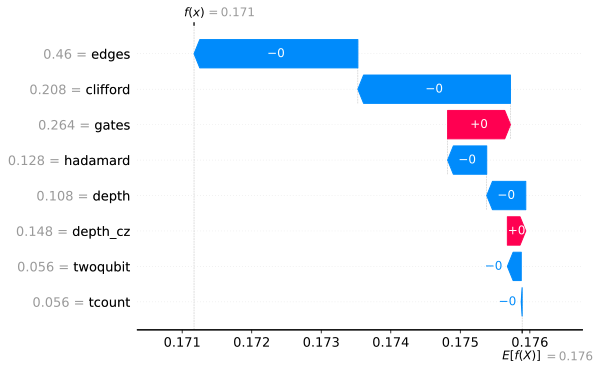

In [6]:
shap.plots.waterfall(shap_values[0])

In [7]:
import pandas as pd
i=0

shap.initjs()
#print("features\n",pd.DataFrame(dataset[i].reshape(1,-1),columns=["gates","tcount","clifford","twoqubit","had","depth","depth_cz","edges"]))
shap.plots.force(shap_values[i])

We can plot the same thing for multiple values (rotated by 90°)

In [8]:
shap.plots.force(shap_values)

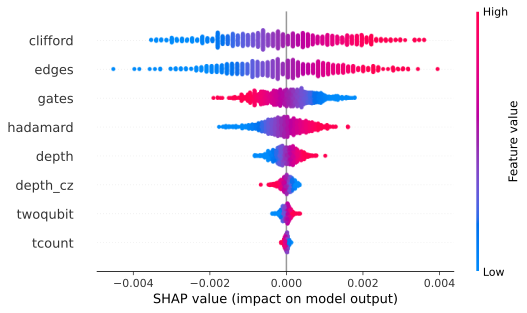

In [9]:
shap.plots.beeswarm(shap_values)

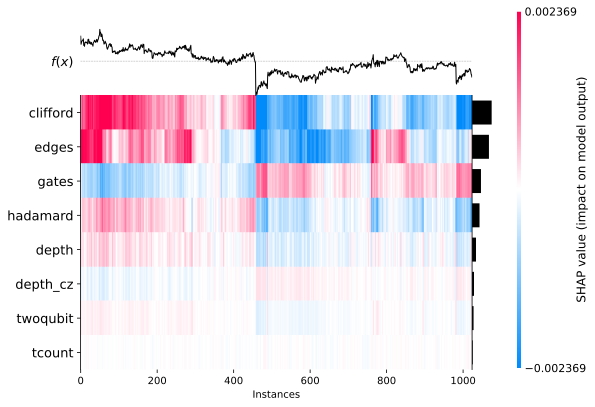

<Axes: xlabel='Instances'>

In [10]:
shap.plots.heatmap(shap_values)

/home/alexander/miniforge3/envs/generalML/lib/python3.10/site-packages/shap/utils/_clustering.py:126: UserWarning: No/low signal found from feature 0 (this is typically caused by constant or near-constant features)! Cluster distances can't be computed for it (so setting all distances to 1).
  warnings.warn(f"No/low signal found from feature {i} (this is typically caused by constant or near-constant features)! Cluster distances can't be computed for it (so setting all distances to 1).")
/home/alexander/miniforge3/envs/generalML/lib/python3.10/site-packages/shap/utils/_clustering.py:126: UserWarning: No/low signal found from feature 1 (this is typically caused by constant or near-constant features)! Cluster distances can't be computed for it (so setting all distances to 1).
  warnings.warn(f"No/low signal found from feature {i} (this is typically caused by constant or near-constant features)! Cluster distances can't be computed for it (so setting all distances to 1).")
/home/alexander/mi

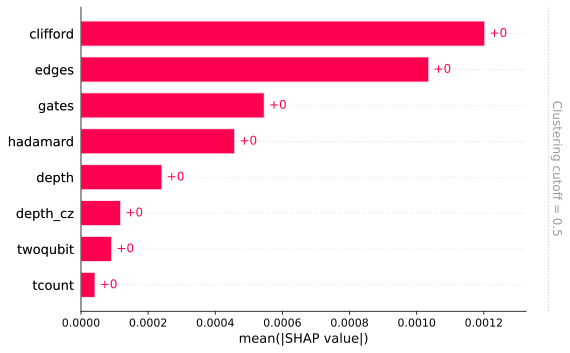

In [11]:
clustering = shap.utils.hclust(dataset.numpy(), m(dataset.numpy()))
shap.plots.bar(shap_values,clustering=clustering)

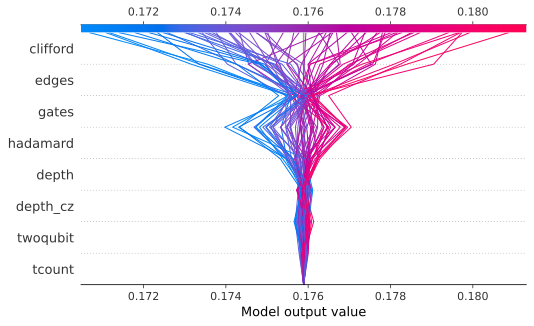

In [12]:
shap.plots.decision(shap_values.base_values.mean(),shap_values[:64].values,shap_values.feature_names)

y [0.17117031 0.178714   0.17410359 ... 0.17084341 0.1740048  0.17138046]


(array([ 1.,  2.,  0.,  2.,  0.,  0.,  3.,  2.,  1.,  9.,  3.,  6.,  6.,
         3., 11.,  9., 11., 20., 25., 22., 18., 19., 37., 39., 21., 44.,
        28., 27., 30., 35., 46., 22., 32., 31., 37., 31., 35., 28., 21.,
        31., 28., 27., 27., 26., 23., 22., 18., 17., 12., 18.,  9., 15.,
         9.,  7.,  7.,  0.,  1.,  4.,  2.,  1.,  1.,  1.,  0.,  1.]),
 array([0.16807073, 0.1683061 , 0.16854145, 0.16877681, 0.16901216,
        0.16924752, 0.16948287, 0.16971824, 0.16995358, 0.17018895,
        0.1704243 , 0.17065966, 0.17089501, 0.17113037, 0.17136572,
        0.17160109, 0.17183644, 0.1720718 , 0.17230715, 0.17254251,
        0.17277786, 0.17301323, 0.17324857, 0.17348394, 0.17371929,
        0.17395465, 0.17419   , 0.17442536, 0.17466071, 0.17489608,
        0.17513143, 0.17536679, 0.17560214, 0.1758375 , 0.17607287,
        0.17630821, 0.17654358, 0.17677893, 0.17701429, 0.17724964,
        0.177485  , 0.17772035, 0.17795572, 0.17819107, 0.17842643,
        0.17866178, 0.1788

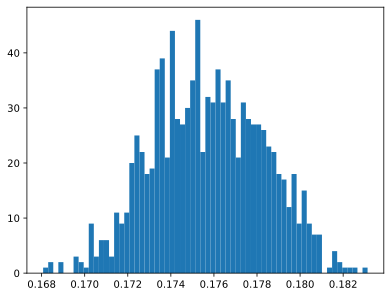

: 

In [13]:
import matplotlib.pyplot as plt
y=m(dataset.numpy())
print("y",y)
plt.hist(y,bins=64)